# LocateAnything-3B — 视觉定位推理服务

NVIDIA 开源的高效视觉-语言定位模型（~3B 参数），采用 **Parallel Box Decoding (PBD)** 技术实现一次性并行预测完整边界框，推理吞吐量最高提升 2.5 倍。

## 一、项目简介

### 1.1 官方简介

LocateAnything 是 NVIDIA 推出的视觉-语言定位（Vision-Language Grounding）模型。核心创新 **Parallel Box Decoding (PBD)** 将完整的边界框作为原子单元一步预测，打破传统逐 token 自回归解码的瓶颈，实现速度和精度的双重提升。

模型在大规模多领域数据集上训练（1200 万张图片、1.38 亿条语言查询、7.85 亿个标注框），支持指代表达接地、密集目标检测、GUI 元素定位、文字检测、点定位等多种任务。

### 1.2 本项目

| 维度 | 内容 |
|------|------|
| **实现类型** | 推理 + WebUI（Gradio 可视界面） |
| **模型** | nvidia/LocateAnything-3B（~3.4B 参数） |
| **框架/引擎** | PyTorch + Transformers 4.57.1 |
| **精度** | bfloat16 |
| **许可证** | NVIDIA License（仅限学术和非营利研究用途） |

### 1.3 界面截图

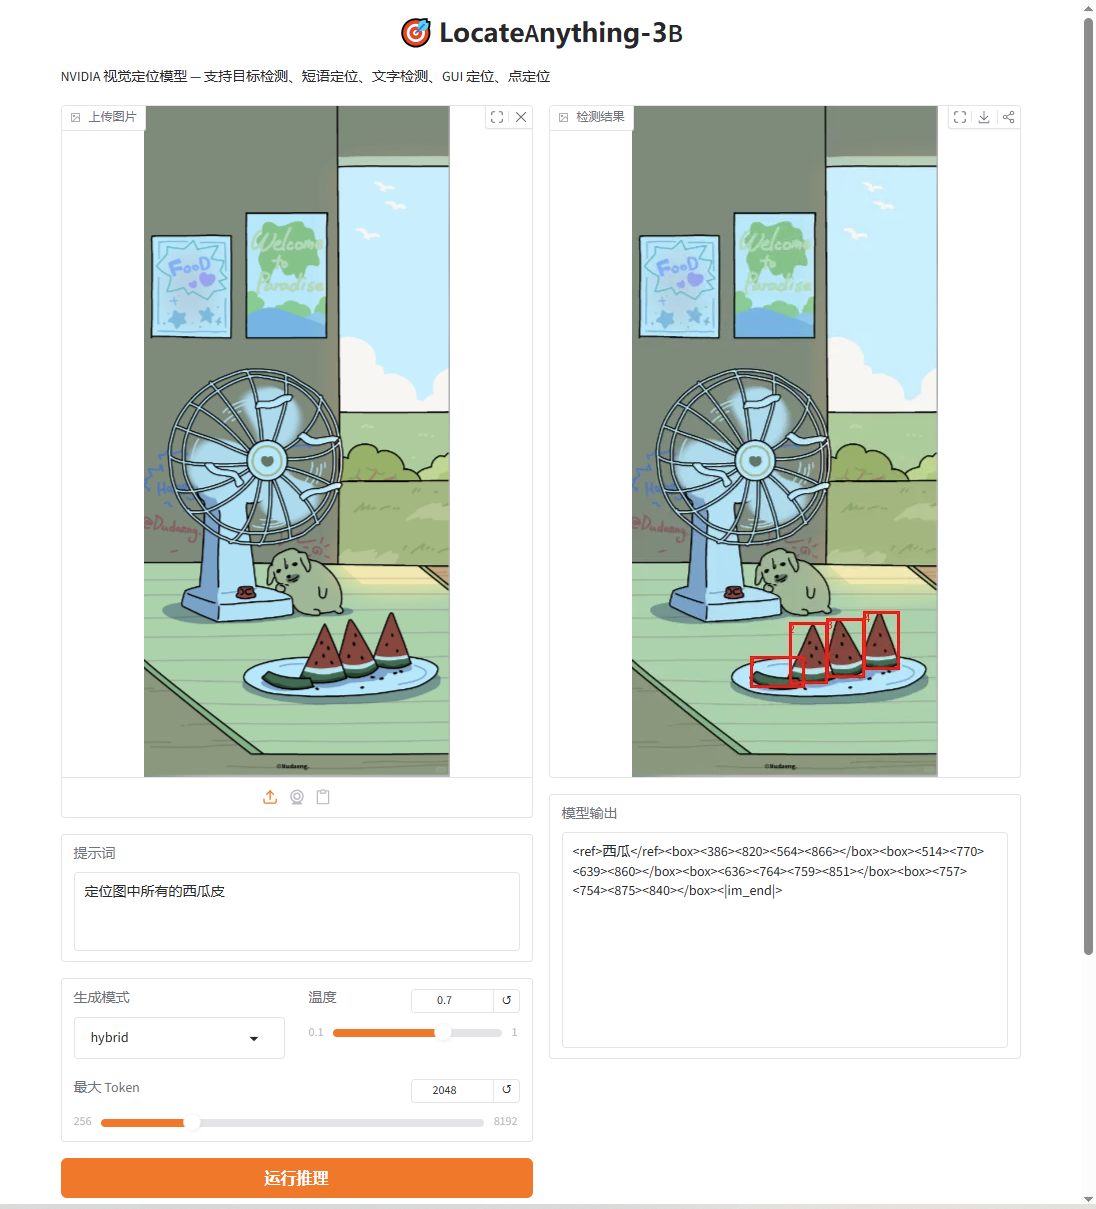

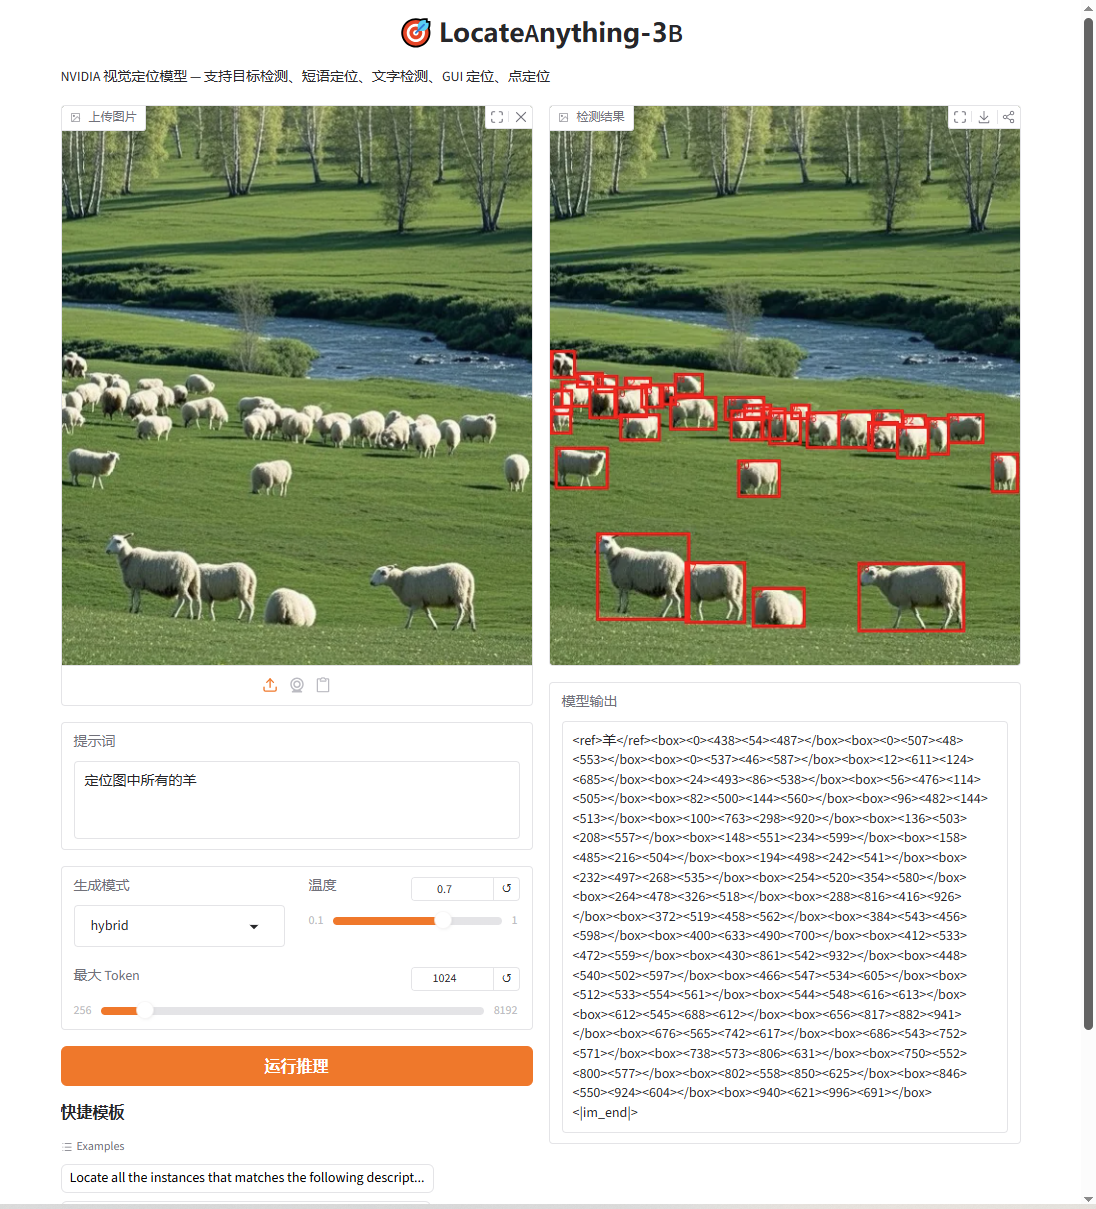

## 二、官方链接

| 类型 | 链接 |
|------|------|
| 🤗 HuggingFace 模型 | [nvidia/LocateAnything-3B](https://huggingface.co/nvidia/LocateAnything-3B) |
| 💻 GitHub 源码 | [NVlabs/Eagle/tree/main/Embodied](https://github.com/NVlabs/Eagle/tree/main/Embodied) |
| 📄 技术报告 | [arXiv:2605.27365](https://arxiv.org/abs/2605.27365) |
| 🌐 项目主页 | [NVIDIA Research](https://research.nvidia.com/labs/lpr/locate-anything/) |
| 📥 模型下载（国内镜像） | [hf-mirror.com/nvidia/LocateAnything-3B](https://hf-mirror.com/nvidia/LocateAnything-3B) |

## 三、算力推荐

| 配置 | GPU 显存 | 推荐规格 | 备注 |
|------|:-------:|:--------:|------|
| **最低配置** | ~6 GB | B1.large（1卡·24GB） | 本服务实际部署规格 |
| **流畅运行** | ~8 GB | B1.large 及以上 | 支持更大图片（1024px+） |

## 四、推理服务配置

| 参数 | 值 |
|------|------|
| **镜像** | `locateanything-3b-inference:latest`（自构建） |
| **模型挂载** | `/gemini/pretrain/LocateAnything-3B-model` |
| **代码文件** | `app.py` + `start.sh`（挂载到 `/gemini/code/`） |
| **启动命令** | `bash /gemini/code/start.sh` |
| **端口** | 7860 |
| **路由模式** | 默认 |
| **公网链接** | http://direct.virtaicloud.com:27598/ |

## 五、使用说明

### 方式一：WebUI（推荐）

浏览器打开公网链接即可使用 Gradio 图形界面：


**操作步骤：**
1. **上传图片** — 点击上传区域选择图片
2. **输入提示词** — describe the object(s) you want to locate
3. **选择模式** — hybrid（推荐）、fast（最快）、slow（最稳）
4. **点击运行推理** — 等待边界框结果


> **一键启动（Jupyter Notebook）：** 如果需要在 Notebook 内直接启动服务，运行下方代码单元格即可，无需打开终端。启动后终端日志会实时显示在单元格输出中。


In [ ]:
# 一键启动推理服务（在 Notebook 中直接运行，无需打开终端）
!cd /gemini/code && python app.py


### 提示词格式

```
# 单目标定位（推荐）
Locate all the instances that matches the following description: dog.

# 多目标检测（用 </c> 分隔不同目标）
Locate all the instances that matches the following description: person.</c>car.</c>bicycle.

# 短语定位（单个实例）
Locate a single instance that matches the following description: the red car.

# 文字检测
Detect all the text in box format.

# 点定位
Point to: the traffic light.
```

### 方式二：API 调用

```python
import requests

url = "http://direct.virtaicloud.com:27598/api/predict"
files = {"image": open("test.jpg", "rb")}
data = {"prompt": "Locate all the instances that matches the following description: cat."}
resp = requests.post(url, files=files, data=data)
print(resp.json())
```

### 注意事项

- **输出格式**：模型只输出 `<ref><box>` 格式坐标，不输出自然语言描述
- **坐标范围**：`<box><x1><y1><x2><y2></box>`，值域 0-1000（归一化坐标）
- **图片尺寸**：Canvas 尺寸较小的图片检测效果更好
- **模型加载**：首次加载约需 30 秒（加载 2/2 个权重分片）
- **兼容性**：flash_attn 不可用，自动回退 sdpa（不影响功能）